# Software Defect Prediction with XGBoost and K-Fold Cross-Validation

This notebook trains XGBoost classifiers on NASA software defect datasets (CM1, JM1, KC1, PC1) using Stratified K-Fold cross-validation, compares results across datasets, and generates predictions on the KC2 blind test set.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import optuna
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All libraries imported successfully.")

All libraries imported successfully.


/home/paul/Documents/00-git-uni/cassino-ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Training Datasets

Load the four NASA software defect datasets. Each dataset contains software module metrics (Halstead, McCabe complexity) and a binary `defects` label (true/false).

The first two rows after the header in each file are metadata rows — we skip them.

In [2]:
# Paths to training datasets
dataset_paths = {
    "CM1": "datasets/datasets/cm1.csv",
    "JM1": "datasets/datasets/jm1.csv",
    "KC1": "datasets/datasets/kc1.csv",
    "PC1": "datasets/datasets/pc1.csv",
}

# Common feature columns (lowercase, consistent naming)
FEATURE_COLS = [
    "loc", "v(g)", "ev(g)", "iv(g)", "n", "v", "l", "d", "i", "e", "b", "t",
    "locode", "locomment", "loblank", "loccodeandcomment",
    "uniq_op", "uniq_opnd", "total_op", "total_opnd", "branchcount",
]

datasets = {}
for name, path in dataset_paths.items():
    df = pd.read_csv(path, skiprows=[1, 2])  # skip metadata rows
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "")
    # Map defects column to binary
    df["defects"] = df["defects"].map({"true": 1, "false": 0, True: 1, False: 0}).astype(int)
    datasets[name] = df
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

datasets["CM1"].head()

CM1: 496 rows, 22 columns
JM1: 13202 rows, 22 columns
KC1: 2107 rows, 22 columns
PC1: 1107 rows, 22 columns


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,locode,locomment,loblank,loccodeandcomment,uniq_op,uniq_opnd,total_op,total_opnd,branchcount,defects
0,24,5,1,3,63,309.13,0.11,9.50,32.54,2936.77,...,1,0,6,0,15,15,44,19,9,0
1,20,4,4,2,47,215.49,0.06,16.00,13.47,3447.89,...,0,0,3,0,16,8,31,16,7,0
2,24,6,6,2,72,346.13,0.06,17.33,19.97,5999.58,...,0,0,3,0,16,12,46,26,11,0
3,24,6,6,2,72,346.13,0.06,17.33,19.97,5999.58,...,0,0,3,0,16,12,46,26,11,0
4,7,1,1,1,11,34.87,0.50,2.00,17.43,69.74,...,0,0,1,0,4,5,6,5,1,0


## 3. Exploratory Data Analysis

Check for missing values, class distributions, and basic statistics per dataset.

In [3]:
# Missing values and class distribution per dataset
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    class_counts = df["defects"].value_counts()
    defect_rate = class_counts.get(1, 0) / len(df) * 100
    print(f"--- {name} ---")
    print(f"  Missing values: {missing}")
    print(f"  Class distribution: No defect={class_counts.get(0, 0)}, Defect={class_counts.get(1, 0)} ({defect_rate:.1f}%)")
    print()

--- CM1 ---
  Missing values: 0
  Class distribution: No defect=448, Defect=48 (9.7%)

--- JM1 ---
  Missing values: 0
  Class distribution: No defect=11100, Defect=2102 (15.9%)

--- KC1 ---
  Missing values: 0
  Class distribution: No defect=1782, Defect=325 (15.4%)

--- PC1 ---
  Missing values: 0
  Class distribution: No defect=1031, Defect=76 (6.9%)



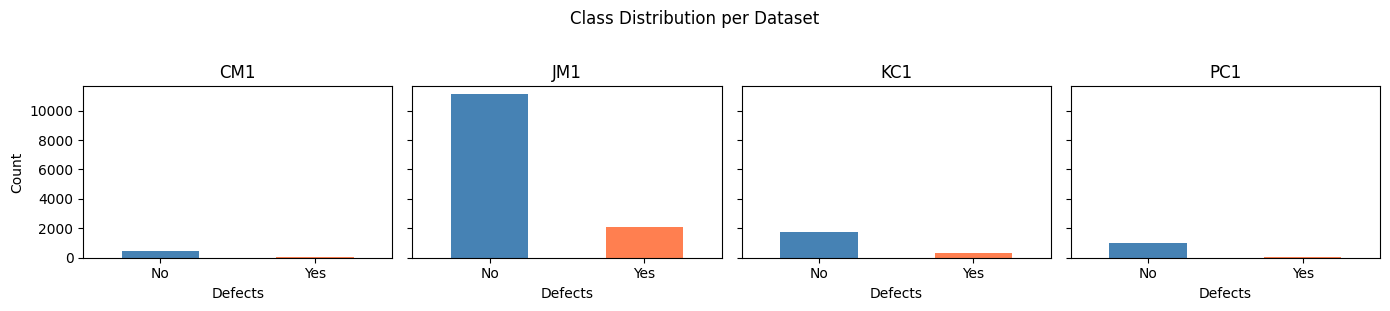

In [4]:
# Class distribution bar chart
fig, axes = plt.subplots(1, len(datasets), figsize=(14, 3), sharey=True)
for ax, (name, df) in zip(axes, datasets.items()):
    df["defects"].value_counts().sort_index().plot.bar(ax=ax, color=["steelblue", "coral"])
    ax.set_title(name)
    ax.set_xlabel("Defects")
    ax.set_ylabel("Count")
    ax.set_xticklabels(["No", "Yes"], rotation=0)
plt.suptitle("Class Distribution per Dataset", y=1.02)
plt.tight_layout()
plt.show()

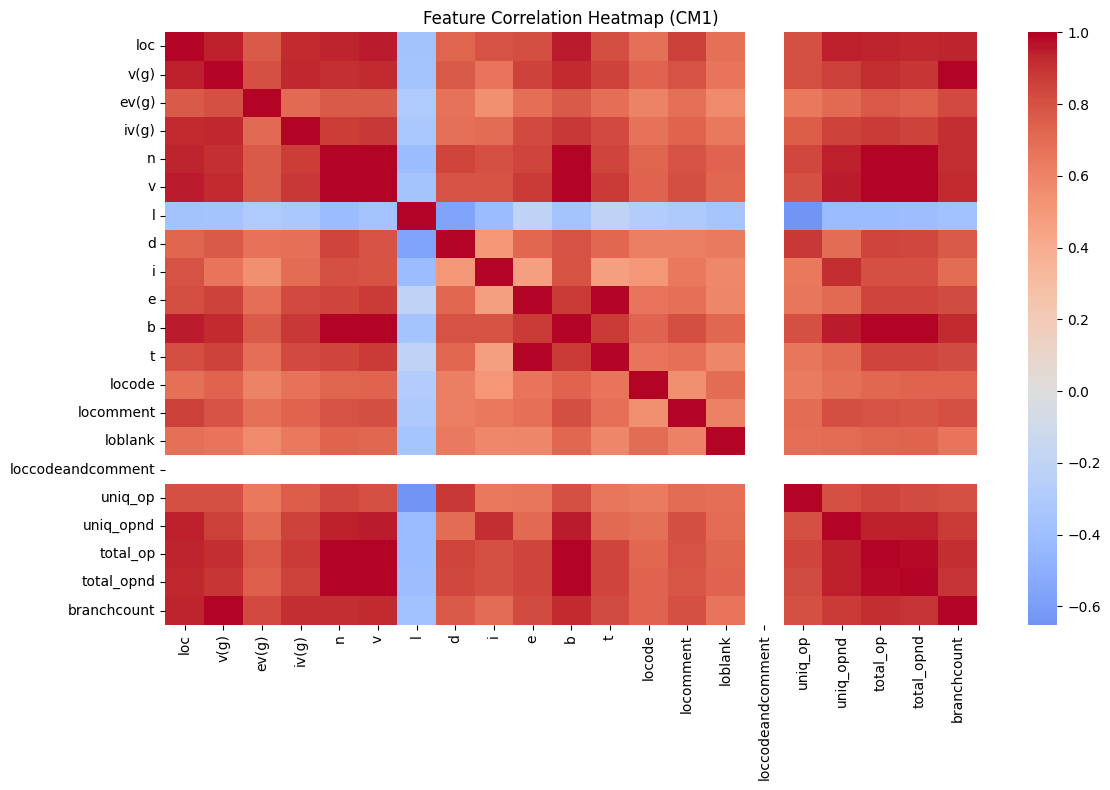

In [5]:
# Correlation heatmap for one example dataset (CM1)
plt.figure(figsize=(12, 8))
corr = datasets["CM1"][FEATURE_COLS].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (CM1)")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Feature Engineering

Standardize column names across datasets, handle missing values, and prepare feature matrices (X) and targets (y).

In [6]:
# Prepare X, y for each dataset using the common feature columns
data_splits = {}
for name, df in datasets.items():
    # Fill missing values with median
    X = df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce").fillna(df[FEATURE_COLS].median())
    y = df["defects"]
    data_splits[name] = (X, y)
    print(f"{name}: X shape={X.shape}, y distribution: {dict(y.value_counts())}")

# Also create a combined dataset from all training data
X_all = pd.concat([data_splits[n][0] for n in data_splits], ignore_index=True)
y_all = pd.concat([data_splits[n][1] for n in data_splits], ignore_index=True)
print(f"\nCombined: X shape={X_all.shape}, y distribution: {dict(y_all.value_counts())}")

CM1: X shape=(496, 21), y distribution: {0: np.int64(448), 1: np.int64(48)}
JM1: X shape=(13202, 21), y distribution: {0: np.int64(11100), 1: np.int64(2102)}
KC1: X shape=(2107, 21), y distribution: {0: np.int64(1782), 1: np.int64(325)}
PC1: X shape=(1107, 21), y distribution: {0: np.int64(1031), 1: np.int64(76)}

Combined: X shape=(16912, 21), y distribution: {0: np.int64(14361), 1: np.int64(2551)}


## 5. Define XGBoost Model and K-Fold Cross-Validation Strategy

We use `StratifiedKFold` (k=5) to preserve class distribution across folds, which is important given the imbalanced nature of defect datasets. XGBoost's `scale_pos_weight` is set to handle class imbalance.

In [7]:
RANDOM_STATE = 42
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def make_xgb_model(scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )

print(f"K-Fold strategy: StratifiedKFold with k={N_SPLITS}")

K-Fold strategy: StratifiedKFold with k=5


## 6. Train XGBoost with K-Fold on Each Dataset

For each dataset, run Stratified K-Fold cross-validation, track accuracy, F1-score, and AUC per fold.

In [8]:
results = {}

for name, (X, y) in data_splits.items():
    # Calculate class imbalance ratio for scale_pos_weight
    neg_count = (y == 0).sum()
    pos_count = (y == 1).sum()
    spw = neg_count / pos_count if pos_count > 0 else 1.0

    fold_metrics = {"accuracy": [], "f1": [], "auc": []}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = make_xgb_model(scale_pos_weight=spw)
        model.fit(X_train, y_train, verbose=False)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        fold_metrics["accuracy"].append(accuracy_score(y_val, y_pred))
        fold_metrics["f1"].append(f1_score(y_val, y_pred))
        fold_metrics["auc"].append(roc_auc_score(y_val, y_proba))

    results[name] = fold_metrics
    print(f"{name}:  Accuracy={np.mean(fold_metrics['accuracy']):.4f} (±{np.std(fold_metrics['accuracy']):.4f})  "
          f"F1={np.mean(fold_metrics['f1']):.4f} (±{np.std(fold_metrics['f1']):.4f})  "
          f"AUC={np.mean(fold_metrics['auc']):.4f} (±{np.std(fold_metrics['auc']):.4f})")

CM1:  Accuracy=0.8669 (±0.0162)  F1=0.1856 (±0.1167)  AUC=0.7580 (±0.0673)
JM1:  Accuracy=0.7668 (±0.0048)  F1=0.4399 (±0.0098)  AUC=0.7563 (±0.0055)
KC1:  Accuracy=0.8144 (±0.0143)  F1=0.4596 (±0.0302)  AUC=0.7937 (±0.0301)
PC1:  Accuracy=0.9296 (±0.0116)  F1=0.4073 (±0.0995)  AUC=0.8755 (±0.0313)


## 7. Evaluate Cross-Validation Results Across Datasets

Compare mean metrics across all datasets to identify which performs best, and visualize with bar charts.

Metric   ACCURACY     AUC      F1
Dataset                          
CM1        0.8669  0.7580  0.1856
JM1        0.7668  0.7563  0.4399
KC1        0.8144  0.7937  0.4596
PC1        0.9296  0.8755  0.4073


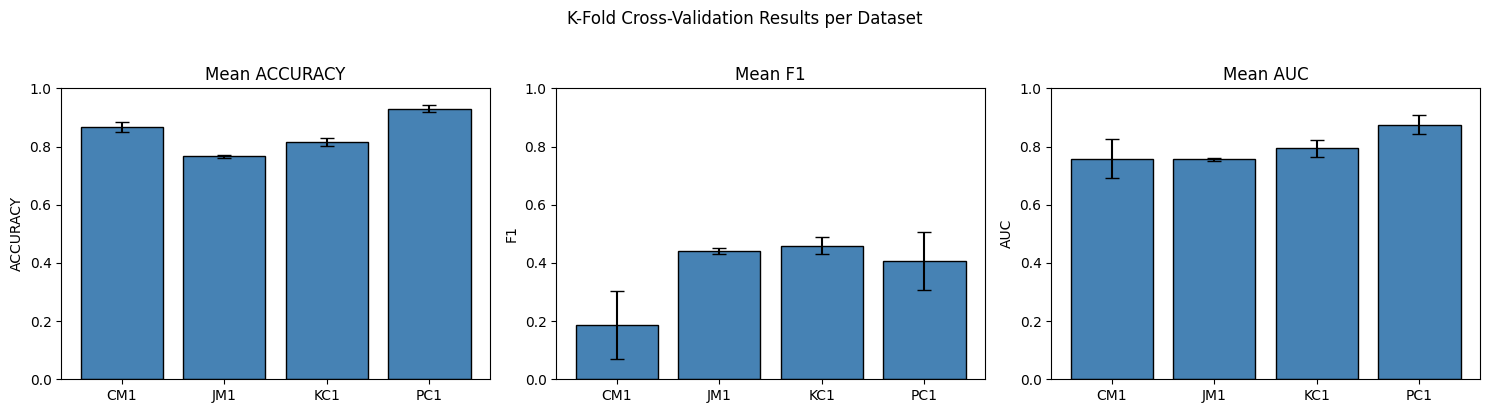

In [9]:
# Build summary table
summary_rows = []
for name, metrics in results.items():
    for metric_name in ["accuracy", "f1", "auc"]:
        summary_rows.append({
            "Dataset": name,
            "Metric": metric_name.upper(),
            "Mean": np.mean(metrics[metric_name]),
            "Std": np.std(metrics[metric_name]),
        })
summary_df = pd.DataFrame(summary_rows)
summary_pivot = summary_df.pivot(index="Dataset", columns="Metric", values="Mean")
print(summary_pivot.round(4).to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["ACCURACY", "F1", "AUC"]):
    metric_data = summary_df[summary_df["Metric"] == metric]
    ax.bar(metric_data["Dataset"], metric_data["Mean"],
           yerr=summary_df[summary_df["Metric"] == metric]["Std"].values,
           capsize=5, color="steelblue", edgecolor="black")
    ax.set_title(f"Mean {metric}")
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric)
plt.suptitle("K-Fold Cross-Validation Results per Dataset", y=1.02)
plt.tight_layout()
plt.show()

## 8. F1-Optimized Hyperparameter Tuning with Optuna + SMOTE

Use Optuna to search for the best XGBoost hyperparameters, optimizing mean F1 score across Stratified K-Fold. SMOTE is applied **inside each fold** to avoid data leakage. We also find the optimal classification threshold.

In [10]:
# Optuna objective: maximize mean F1 across K-Fold with SMOTE
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 15.0),
    }
    
    f1_scores = []
    smote = SMOTE(random_state=RANDOM_STATE)
    
    for train_idx, val_idx in skf.split(X_all, y_all):
        X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
        y_train, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]
        
        # Apply SMOTE only on training fold
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        
        model = XGBClassifier(
            **params,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
        )
        model.fit(X_train_res, y_train_res, verbose=False)
        
        y_pred = model.predict(X_val)
        f1_scores.append(f1_score(y_val, y_pred))
    
    return np.mean(f1_scores)

# Run optimization (100 trials)
study = optuna.create_study(direction="maximize", study_name="xgb_f1_opt")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nBest F1 score (CV mean): {study.best_value:.4f}")
print(f"Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 24. Best value: 0.427553:  27%|██▋       | 27/100 [02:51<07:42,  6.34s/it]


[W 2026-03-23 11:17:28,462] Trial 27 failed with parameters: {'n_estimators': 617, 'max_depth': 10, 'learning_rate': 0.051713362894719804, 'subsample': 0.7640325044449908, 'colsample_bytree': 0.6194665730367412, 'min_child_weight': 2, 'gamma': 0.257135765474605, 'reg_alpha': 0.27395144178230485, 'reg_lambda': 2.8805440113397043, 'scale_pos_weight': 5.225155614991452} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/paul/Documents/00-git-uni/cassino-ml/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_16782/3618612270.py", line 32, in objective
    model.fit(X_train_res, y_train_res, verbose=False)
  File "/home/paul/Documents/00-git-uni/cassino-ml/.venv/lib/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/home/paul/Documents/00-git-u

KeyboardInterrupt: 

Optimal threshold: 0.46
Best OOF F1 at optimal threshold: 0.4291
OOF F1 at default 0.5 threshold: 0.4276


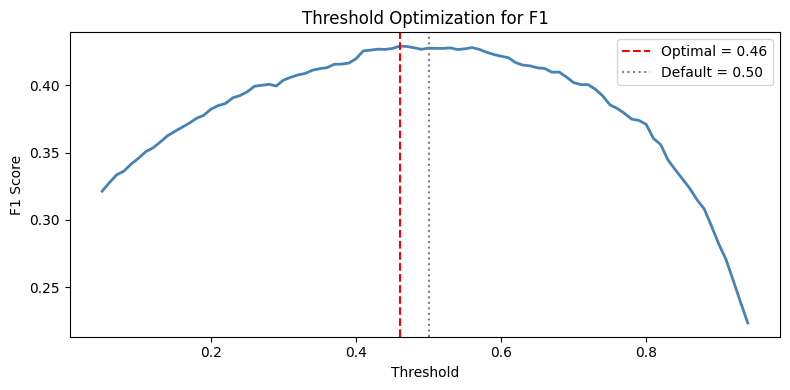


Final optimized model trained on SMOTE-resampled data (28722 samples).


In [11]:
# Train final optimized model with SMOTE + find optimal threshold
best_params = study.best_params
smote = SMOTE(random_state=RANDOM_STATE)

# Collect out-of-fold predictions for threshold optimization
oof_proba = np.zeros(len(y_all))
oof_true = np.zeros(len(y_all))

for train_idx, val_idx in skf.split(X_all, y_all):
    X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_train, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]
    
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
    model = XGBClassifier(
        **best_params,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_res, y_train_res, verbose=False)
    
    oof_proba[val_idx] = model.predict_proba(X_val)[:, 1]
    oof_true[val_idx] = y_val.values

# Sweep thresholds to find optimal for F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_by_thresh = [f1_score(oof_true, (oof_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_by_thresh)]
best_f1 = max(f1_by_thresh)

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Best OOF F1 at optimal threshold: {best_f1:.4f}")
print(f"OOF F1 at default 0.5 threshold: {f1_score(oof_true, (oof_proba >= 0.5).astype(int)):.4f}")

# Plot threshold vs F1
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_by_thresh, color="steelblue", linewidth=2)
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Optimal = {best_threshold:.2f}")
plt.axvline(x=0.5, color="gray", linestyle=":", label="Default = 0.50")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization for F1")
plt.legend()
plt.tight_layout()
plt.show()

# Train final model on ALL data with SMOTE
X_all_res, y_all_res = smote.fit_resample(X_all, y_all)
final_model = XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)
final_model.fit(X_all_res, y_all_res, verbose=False)
print(f"\nFinal optimized model trained on SMOTE-resampled data ({len(X_all_res)} samples).")

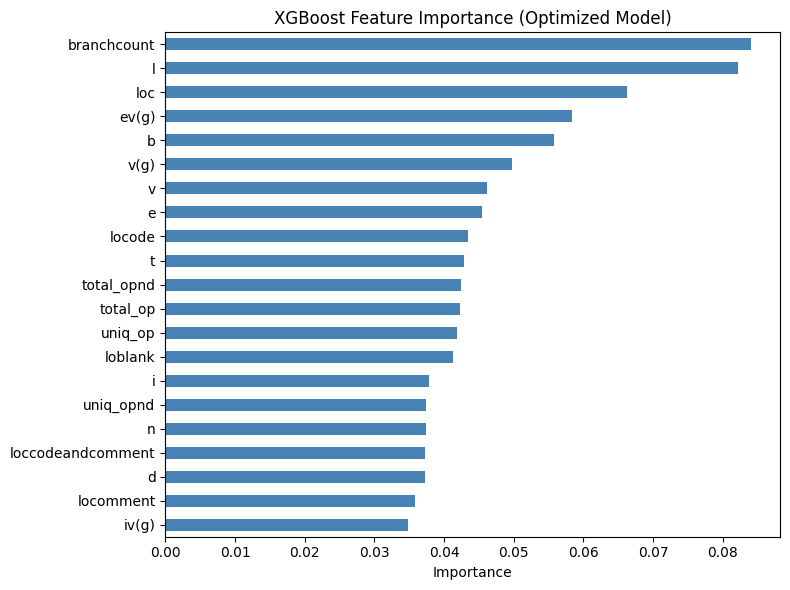

In [12]:
# Feature importance from the final optimized model
importance = pd.Series(final_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
importance.plot.barh(color="steelblue")
plt.title("XGBoost Feature Importance (Optimized Model)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Load and Preprocess Blind Test Dataset (KC2)

Load the KC2 blind test set, align its columns with the training features, and apply the same preprocessing.

In [14]:
# Load blind test set
blind_df = pd.read_csv("test-blind/test-blind/kc2_test_blind.csv", skiprows=[1, 2])
blind_df.columns = blind_df.columns.str.strip().str.lower().str.replace(" ", "")

print(f"Blind test set shape: {blind_df.shape}")
print(f"Columns: {list(blind_df.columns)}")
blind_df.head()

Blind test set shape: (520, 21)
Columns: ['id', 'loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'locode', 'locomment', 'loblank', 'uniq_op', 'uniq_opnd', 'total_op', 'total_opnd', 'branchcount']


,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,b,t,locode,locomment,loblank,uniq_op,uniq_opnd,total_op,total_opnd,branchcount
0,2,415.0,59.0,50.0,51.0,1159.0,8411.31,0.01,103.53,81.24,...,2.80,48380.48,359,35,9,47.0,106.0,692.0,467.0,106.0
1,3,230.0,33.0,10.0,16.0,575.0,3732.82,0.03,39.82,93.74,...,1.24,8258.00,174,15,34,23.0,67.0,343.0,232.0,65.0
2,4,175.0,26.0,12.0,13.0,500.0,3123.96,0.03,29.48,105.96,...,1.04,5116.84,142,7,19,18.0,58.0,310.0,190.0,51.0
3,5,163.0,16.0,13.0,11.0,440.0,2714.77,0.03,32.25,84.14,...,0.90,4866.09,139,2,20,19.0,53.0,260.0,180.0,31.0
4,6,152.0,11.0,6.0,11.0,432.0,2629.78,0.03,31.68,83.01,...,0.88,4628.42,114,18,17,18.0,50.0,256.0,176.0,21.0


In [15]:
# Prepare blind test features (same columns as training)
# The blind set has an 'id' column and no 'defects' column
blind_ids = blind_df["id"] if "id" in blind_df.columns else blind_df.index

# Add any missing feature columns (e.g. loccodeandcomment) with 0
for col in FEATURE_COLS:
    if col not in blind_df.columns:
        blind_df[col] = 0
        print(f"  Column '{col}' missing in blind set — filled with 0")

X_blind = blind_df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce")
# Fill any missing values with the median from the training data
for col in FEATURE_COLS:
    if X_blind[col].isnull().any():
        X_blind[col] = X_blind[col].fillna(X_all[col].median())

print(f"Blind test features shape: {X_blind.shape}")
print(f"Missing values: {X_blind.isnull().sum().sum()}")

  Column 'loccodeandcomment' missing in blind set — filled with 0
Blind test features shape: (520, 21)
Missing values: 0


## 10. Predict on Blind Test Set

Generate predictions using the Optuna-tuned XGBoost model with the F1-optimal threshold. Output format: `id` (0–521), `defects` (1 = buggy, 0 = clean).

In [16]:
# Predict on blind test set using optimized XGBoost + optimal threshold
blind_proba = final_model.predict_proba(X_blind)[:, 1]
blind_preds = (blind_proba >= best_threshold).astype(int)

# Build submission DataFrame (required format: id, defects)
predictions_df = pd.DataFrame({
    "id": range(len(blind_preds)),
    "defects": blind_preds,
})

print(f"Using threshold: {best_threshold:.2f}")
print(f"\nPrediction distribution:")
print(predictions_df["defects"].value_counts().rename({0: "clean (0)", 1: "buggy (1)"}))
print(f"\nTotal predictions: {len(predictions_df)}")
predictions_df.head(10)

Using threshold: 0.46

Prediction distribution:
defects
clean (0)    365
buggy (1)    155
Name: count, dtype: int64

Total predictions: 520


,id,defects
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1
5,5,0
6,6,1
7,7,0
8,8,0
9,9,0


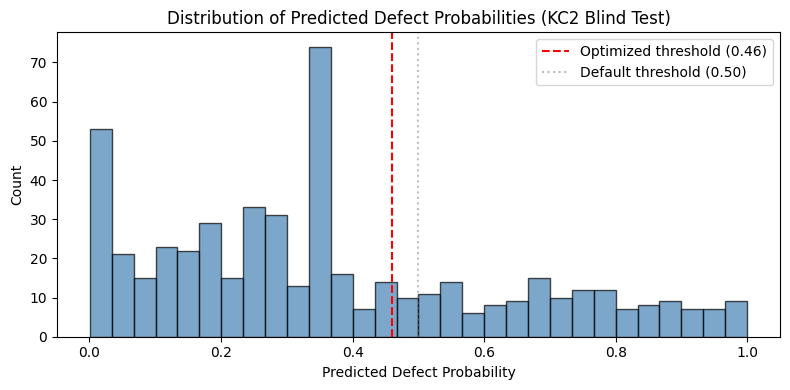

In [17]:
# Visualize prediction probability distribution
plt.figure(figsize=(8, 4))
plt.hist(blind_proba, bins=30, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Optimized threshold ({best_threshold:.2f})")
plt.axvline(x=0.5, color="gray", linestyle=":", alpha=0.5, label="Default threshold (0.50)")
plt.xlabel("Predicted Defect Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Defect Probabilities (KC2 Blind Test)")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Save predictions in submission format
output_path = "kc2_blind_predictions.csv"
predictions_df.to_csv(output_path, index=False)
print(f"Predictions saved to {output_path}")
print(f"\nExpected format: id,defects")
print(predictions_df.head().to_string(index=False))

Predictions saved to kc2_blind_predictions.csv

Expected format: id,defects
 id  defects
  0        1
  1        1
  2        1
  3        1
  4        1
